<a href="https://colab.research.google.com/github/anaghara/EcomStream-Real-time-E-commerce-Analytics-Pipeline/blob/main/churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data cleaning

In [ ]:
# Data Handling & Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Date & Time Processing
from datetime import datetime, timedelta

# Preprocessing & Feature Engineering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.impute import SimpleImputer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Time Series Tools (optional/advanced)
import statsmodels.api as sm
from prophet import Prophet  # install via: pip install prophet
from sklearn.pipeline import Pipeline

# Deep Learning (optional for LSTM)
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("churn_prediction.csv")

# Convert 'date' to datetime with day-first formatting
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Sort by user and date
df = df.sort_values(by=['user_id', 'date'])

# Forward and backward fill for time-based features using transform
for col in ['messages_sent', 'avg_session_duration', 'campaigns_launched']:
    df[col] = df.groupby('user_id')[col].transform(lambda x: x.ffill().bfill())

# Impute total_sessions with user-level median
df['total_sessions'] = df.groupby('user_id')['total_sessions'].transform(lambda x: x.fillna(x.median()))

# Impute active_day with user-level mode (with fallback)
df['active_day'] = df.groupby('user_id')['active_day'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
)

# Final check for remaining missing values
print(df.isnull().sum())


user_id                 0
date                    0
total_sessions          0
messages_sent           0
campaigns_launched      0
avg_session_duration    0
active_day              0
churned                 0
dtype: int64


A **good dataset shape** is one that aligns with the type of problem you're solving and provides enough meaningful data for accurate modeling. For time series problems, this typically means having multiple rows per user, sorted by date, to capture behavior over time. In contrast, for a classification model, you often work with one row per user, with aggregated features summarizing their behavior. A well-shaped dataset also follows the 10× rule — meaning you should ideally have at least 10 times more rows (examples) than columns (features) to avoid overfitting and ensure generalization. A manageable number of features (typically between 5 to 50) is ideal; datasets with hundreds or thousands of features may require dimensionality reduction or feature selection to remain effective. In addition to this, the dataset should be complete — meaning it should not contain excessive missing values, null columns, or duplicate records.

On the other hand, a bad shape indicates that the dataset is not yet ready for modeling. This could mean too few rows, such as 50 records with 20 features, which is likely to cause overfitting. Another red flag is too many features with too few rows (e.g., 200 rows × 1000 columns), which leads to the curse of dimensionality — a situation where the model cannot find meaningful patterns due to sparse or excessive feature space. Sparse data, where many values are missing or filled with zeros, can also make learning difficult. Finally, a dataset with an imbalanced target variable (for example, 99% non-churned and only 1% churned) may lead to misleadingly high accuracy and require balancing strategies like SMOTE or class weighting.**bold text**

Once you've reviewed the **summary statistics** using .describe(), the next step is to interpret those values and take meaningful action. If the count is lower than the total number of rows, it indicates missing values in that column. In this case, you should consider filling in the gaps using imputation methods such as mean, median, or forward fill — or you might choose to drop those rows entirely if appropriate. If the min value is 0 or very small for features like sessions or messages, it may suggest that some users didn’t use the platform at all. These users could be flagged as at-risk for churn or removed if they aren't useful for your analysis.

When you see a very high max value, it means a few users are extremely active, which can act as outliers and distort the data. To fix this, you might apply transformations like clipping, log-scaling, or standardizing the values. A high standard deviation (std) tells you that the data is widely spread out, so using normalization techniques such as StandardScaler can help bring consistency, especially before feeding the data into a machine learning model. Finally, if the mean is much higher or lower than the median (50%), the data is likely skewed. In that case, a log transformation or box-cox transformation can help make the data distribution more normal and easier for models to learn from.

**bold text**
churned
Mean = 0.14, meaning ~14.6% churned.

🔹 Insight: Your data is imbalanced — only ~15% of users churned.

**Things to take care wen dealing with the summary ststistics**
imbalance
Only apply transformations where they are actually needed, based on:
Outliers (extreme values that skew the distribution)

Skewed data (mean far from median)

Wide ranges (large standard deviation)

Model sensitivity (some models are affected more by scales or distributions)

🔹 Dataset shape: (45000, 8)

🔹 First few rows:
  user_id       date  total_sessions  messages_sent  campaigns_launched  \
0   U0001 2024-03-01               4            3.0                 0.0   
1   U0001 2024-03-02               1            5.0                 0.0   
2   U0001 2024-03-03               3            4.0                 0.0   
3   U0001 2024-03-04               2            2.0                 1.0   
4   U0001 2024-03-05               3            8.0                 0.0   

   avg_session_duration  active_day  churned  
0                  9.06           1        0  
1                 11.09           1        0  
2                  8.80           1        0  
3                 11.89           1        0  
4                 11.89           1        0  

🔹 Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------         

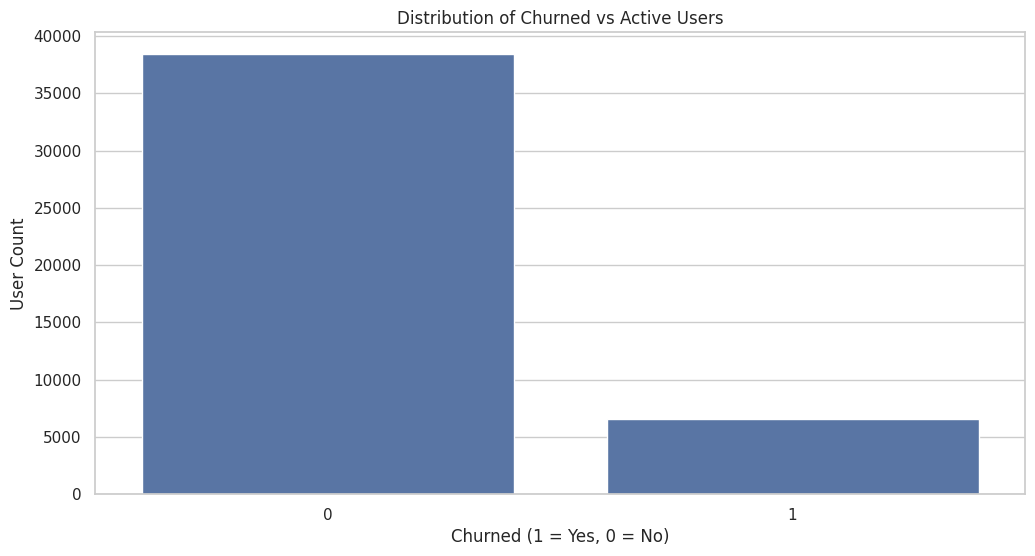

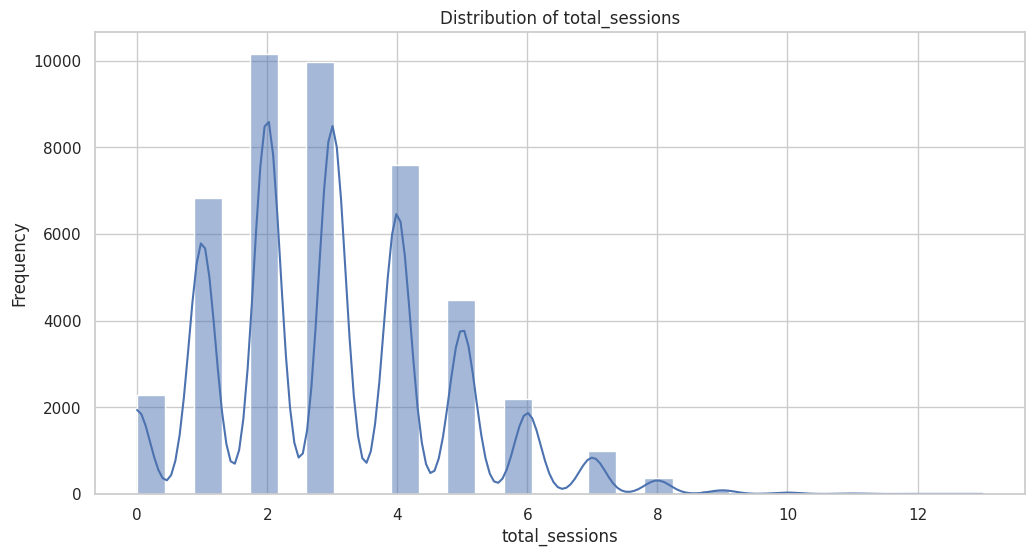

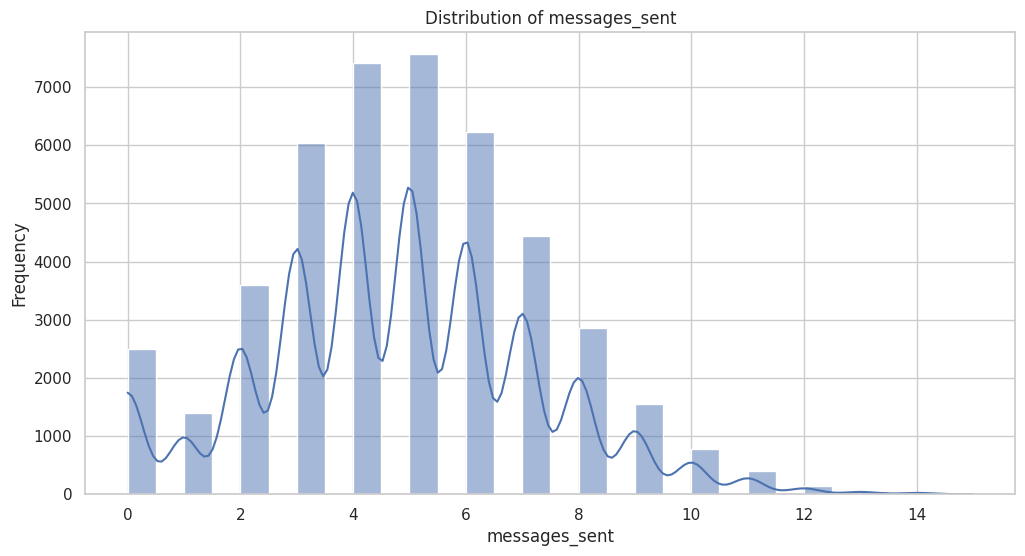

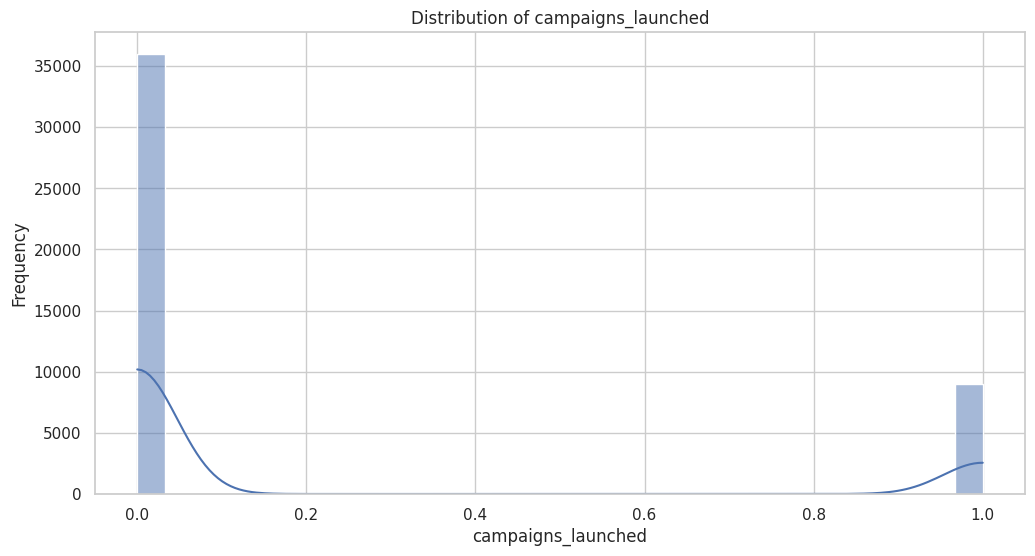

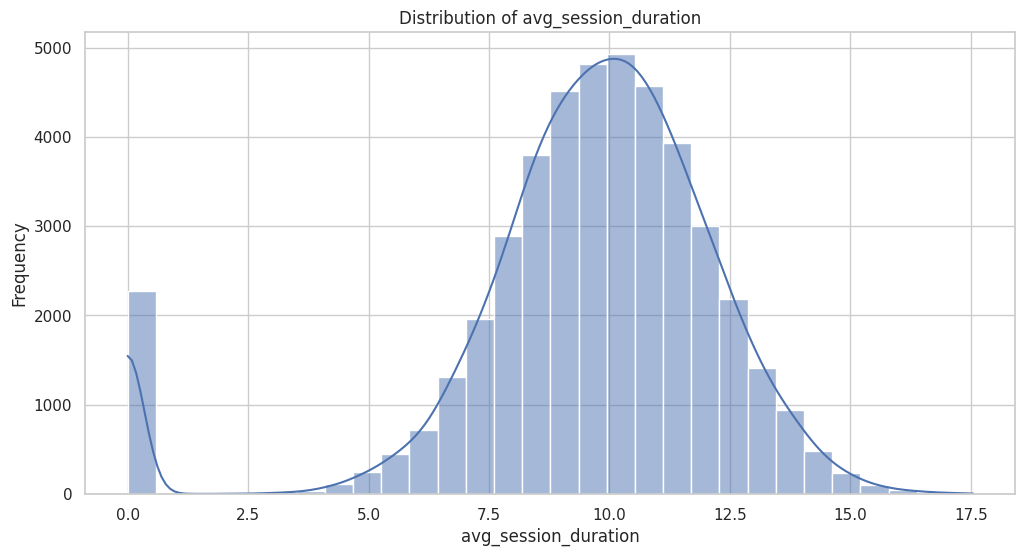

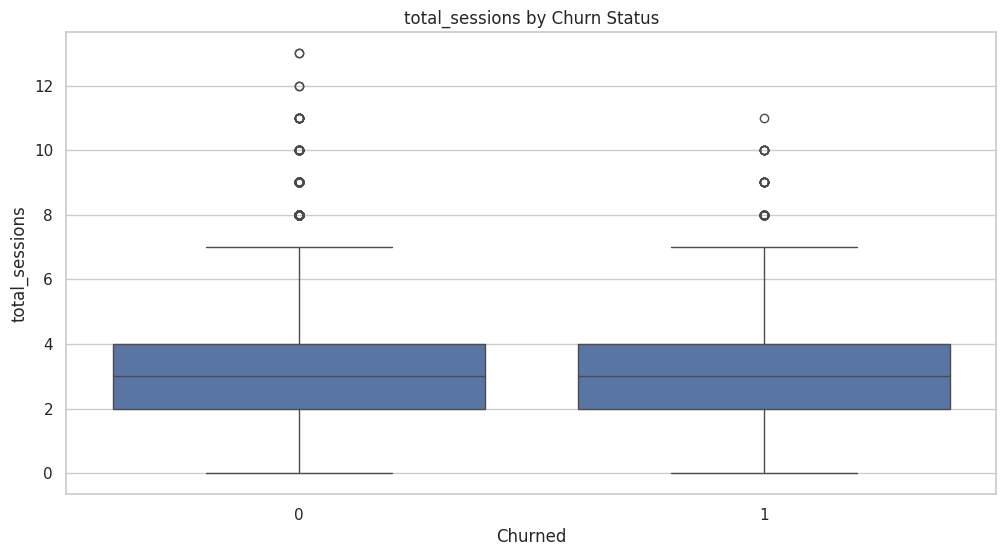

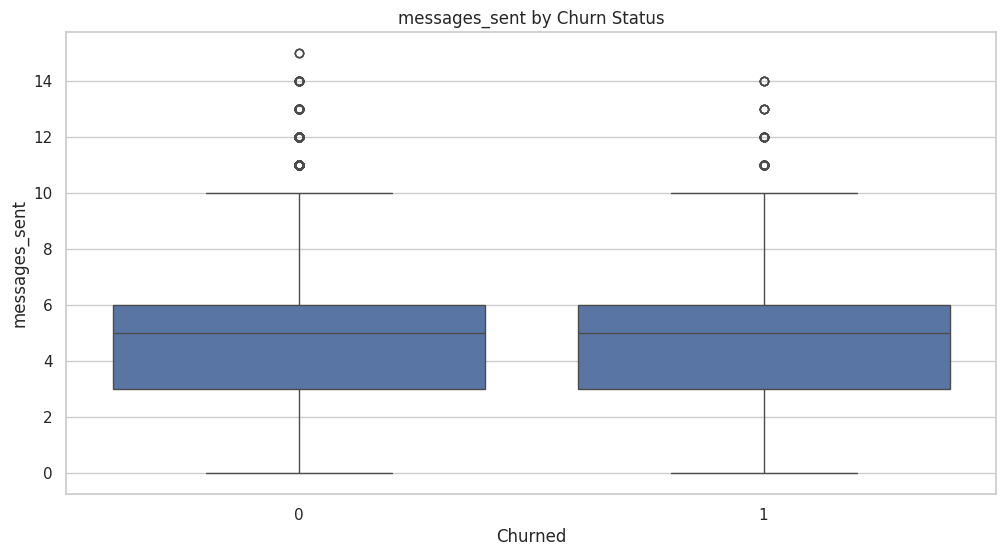

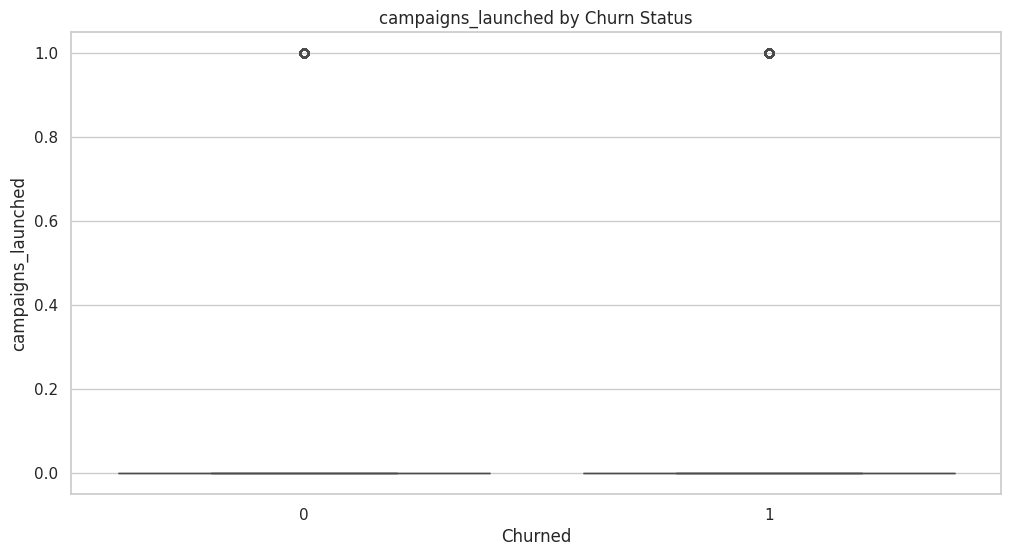

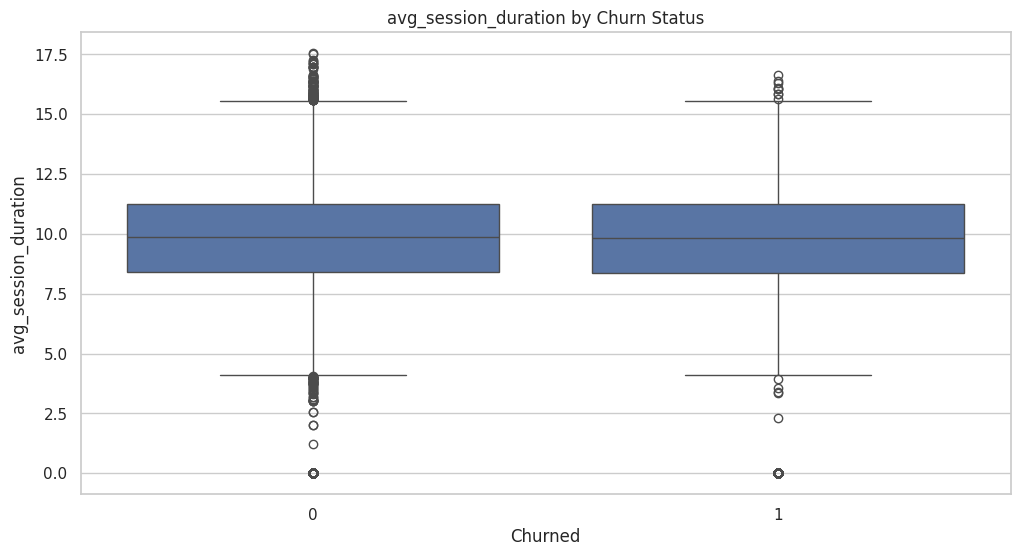

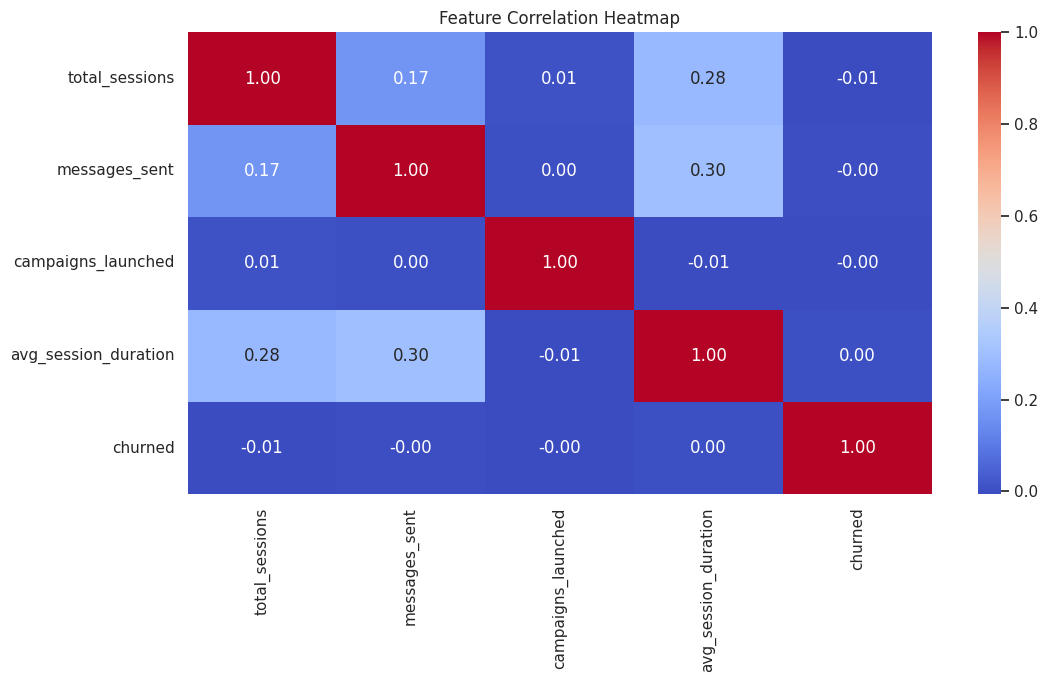

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Basic structure of the dataset
print("🔹 Dataset shape:", df.shape)
print("\n🔹 First few rows:")
print(df.head())

# 2. Data types and missing values
print("\n🔹 Data types and missing values:")
print(df.info())
print("\n🔹 Total missing values per column:")
print(df.isnull().sum())

# 3. Summary statistics
print("\n🔹 Summary statistics:")
print(df.describe())

# 4. Target variable distribution
sns.countplot(x='churned', data=df)
plt.title('Distribution of Churned vs Active Users')
plt.xlabel('Churned (1 = Yes, 0 = No)')
plt.ylabel('User Count')
plt.show()

# 5. Histograms for numerical features
num_cols = ['total_sessions', 'messages_sent', 'campaigns_launched', 'avg_session_duration']

for col in num_cols:
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# 6. Compare feature distributions by churn status
for col in num_cols:
    sns.boxplot(x='churned', y=col, data=df)
    plt.title(f'{col} by Churn Status')
    plt.xlabel('Churned')
    plt.ylabel(col)
    plt.show()

# 7. Correlation heatmap
corr_matrix = df[num_cols + ['churned']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# -------------------------------
# 🧹 1. Outlier Capping & Log Transform
# -------------------------------

# Cap total_sessions at 95th percentile and log-transform
session_cap = df['total_sessions'].quantile(0.95)
df['total_sessions_capped'] = np.where(df['total_sessions'] > session_cap, session_cap, df['total_sessions'])
df['log_total_sessions'] = np.log1p(df['total_sessions_capped'])

# Log-transform avg_session_duration
df['log_session_duration'] = np.log1p(df['avg_session_duration'])

# Optional scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['log_total_sessions', 'log_session_duration']])
df[['scaled_total_sessions', 'scaled_session_duration']] = scaled_features

# -------------------------------
# 🎯 2. Select Base Features (you will expand this with engineered ones)
# -------------------------------
features = ['scaled_total_sessions', 'messages_sent', 'scaled_session_duration', 'active_day', 'campaigns_launched']
X = df[features]
y = df['churned']

# -------------------------------
# ✂️ 3. Train-test split (Stratified)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)



In [ ]:
# Make sure date is in datetime format and sorted
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values(by=['user_id', 'date'])

# 1. Rolling averages (7-day window)
df['rolling_sessions_7'] = df.groupby('user_id')['total_sessions'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df['rolling_messages_7'] = df.groupby('user_id')['messages_sent'].transform(lambda x: x.rolling(7, min_periods=1).mean())

# 2. Lag features (previous day's activity)
df['lag_sessions_1'] = df.groupby('user_id')['total_sessions'].shift(1)
df['lag_messages_1'] = df.groupby('user_id')['messages_sent'].shift(1)

# 3. Inactivity streaks (flag 0 session days)
df['is_inactive'] = (df['total_sessions'] == 0).astype(int)
df['inactive_days_7'] = df.groupby('user_id')['is_inactive'].transform(lambda x: x.rolling(7, min_periods=1).sum())

# 4. Overall average per user
df['avg_sessions_all'] = df.groupby('user_id')['total_sessions'].transform('mean')

# 5. Engagement drop ratio (recent / long-term)
df['engagement_ratio'] = df['rolling_sessions_7'] / (df['avg_sessions_all'] + 1e-6)

# 6. Volatility (how much their usage changes)
df['session_volatility_7'] = df.groupby('user_id')['total_sessions'].transform(lambda x: x.rolling(7, min_periods=1).std())

# Preview new features
df[['user_id', 'date', 'total_sessions', 'rolling_sessions_7', 'lag_sessions_1', 'inactive_days_7', 'engagement_ratio', 'session_volatility_7']].head(10)


,user_id,date,total_sessions,rolling_sessions_7,lag_sessions_1,inactive_days_7,engagement_ratio,session_volatility_7
0,U0001,2024-03-01,4,4.000000,NaN,0.0,1.428571,NaN
1,U0001,2024-03-02,1,2.500000,4.0,0.0,0.892857,2.121320
2,U0001,2024-03-03,3,2.666667,1.0,0.0,0.952381,1.527525
3,U0001,2024-03-04,2,2.500000,3.0,0.0,0.892857,1.290994
4,U0001,2024-03-05,3,2.600000,2.0,0.0,0.928571,1.140175
5,U0001,2024-03-06,3,2.666667,3.0,0.0,0.952381,1.032796
6,U0001,2024-03-07,2,2.571429,3.0,0.0,0.918367,0.975900
7,U0001,2024-03-08,1,2.142857,2.0,0.0,0.765306,0.899735
8,U0001,2024-03-09,4,2.571429,1.0,0.0,0.918367,0.975900
9,U0001,2024-03-10,3,2.571429,4.0,0.0,0.918367,0.975900


In [ ]:
# Group by user_id and summarize key features
user_features = df.groupby('user_id').agg({
    'total_sessions': ['mean', 'max', 'min'],
    'messages_sent': ['mean', 'std'],
    'rolling_sessions_7': 'last',
    'engagement_ratio': 'last',
    'inactive_days_7': 'max',
    'session_volatility_7': 'last',
    'churned': 'max'  # Assuming churn is same per user
})

# Flatten the MultiIndex columns
user_features.columns = ['_'.join(col).strip() for col in user_features.columns.values]
user_features.reset_index(inplace=True)

# Final preview
user_features.head()


,user_id,total_sessions_mean,total_sessions_max,total_sessions_min,messages_sent_mean,messages_sent_std,rolling_sessions_7_last,engagement_ratio_last,inactive_days_7_max,session_volatility_7_last,churned_max
0,U0001,2.800000,7,0,4.133333,2.417370,2.285714,0.816326,1.0,1.799471,0
1,U0002,2.900000,7,1,5.133333,2.359622,1.714286,0.591133,0.0,0.487950,0
2,U0003,2.866667,5,0,4.400000,2.711406,2.714286,0.946844,2.0,1.253566,0
3,U0004,3.033333,6,0,4.466667,2.763473,4.000000,1.318681,1.0,0.816497,0
4,U0005,3.600000,7,1,4.066667,2.083322,3.000000,0.833333,0.0,1.632993,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 🎯 1. Select Features & Target
# -------------------------------
X = user_features.drop(columns=['user_id', 'churned_max'])  # drop ID and target
y = user_features['churned_max']

# Optional: scale features (tree models don't need it, but others might)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# ✂️ 2. Train-Test Split (Stratified)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y, test_size=0.2, random_state=42)

# -------------------------------
# ⚖️ 3. Apply SMOTE to Training Data
# -------------------------------
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# -------------------------------
# 🌲 4. Train a Random Forest Model
# -------------------------------
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_balanced, y_train_balanced)

# -------------------------------
# 📊 5. Evaluate the Model
# -------------------------------
y_pred = clf.predict(X_test)

print("🔍 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📄 Classification Report:\n", classification_report(y_test, y_pred))


🔍 Confusion Matrix:
 [[235  21]
 [ 42   2]]

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.88       256
           1       0.09      0.05      0.06        44

    accuracy                           0.79       300
   macro avg       0.47      0.48      0.47       300
weighted avg       0.74      0.79      0.76       300



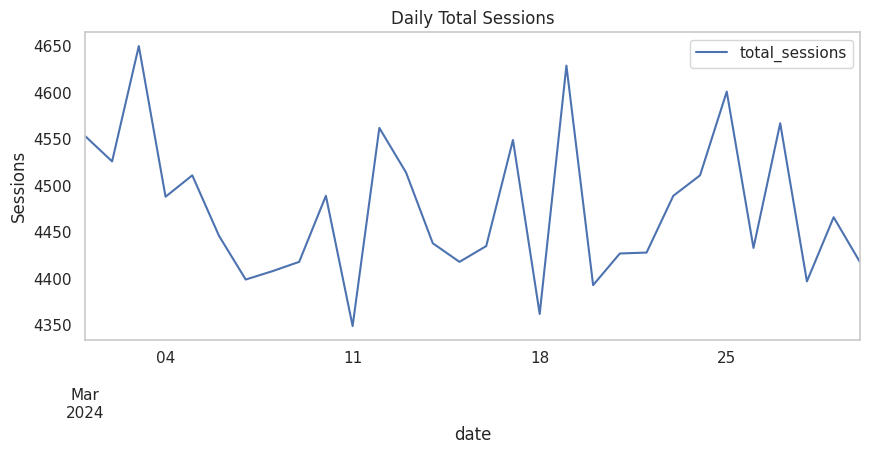

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2juyi5ra/ow_a_5ss.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2juyi5ra/0k1h3fay.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=25115', 'data', 'file=/tmp/tmp2juyi5ra/ow_a_5ss.json', 'init=/tmp/tmp2juyi5ra/0k1h3fay.json', 'output', 'file=/tmp/tmp2juyi5ra/prophet_modeli0navqhl/prophet_model-20250423201952.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
20:19:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:19:52 - cmdstanpy - INFO - Chain [1] done processing
INFO:

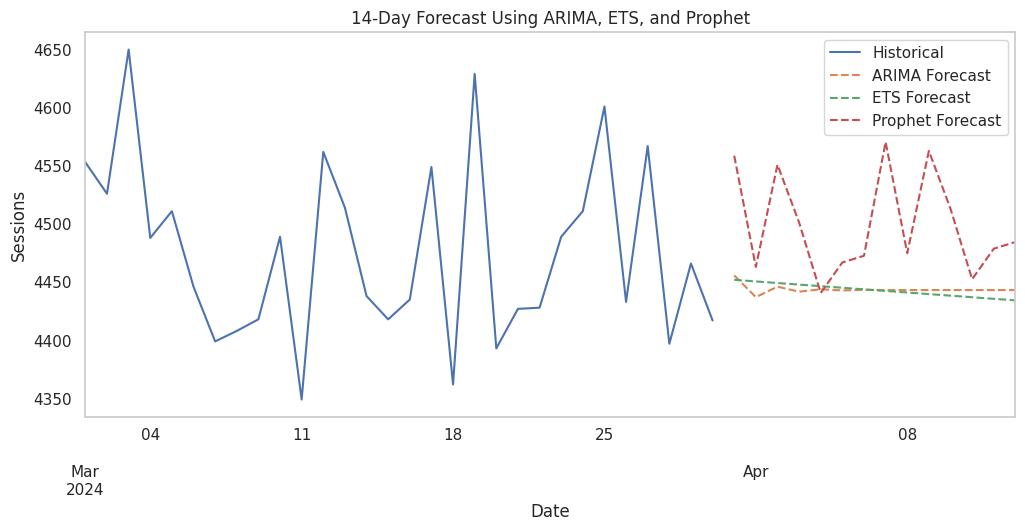

In [ ]:
# ---------------------------------------
# 1. Imports
# ---------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

# ---------------------------------------
# 2. Data Cleaning
# ---------------------------------------
# Assuming df has 'date' and 'total_sessions'
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values(by='date')

# Group by date to get daily platform-level sessions
daily_df = df.groupby('date')['total_sessions'].sum().reset_index()

# Fill missing dates
daily_df = daily_df.set_index('date').asfreq('D')
daily_df['total_sessions'] = daily_df['total_sessions'].fillna(method='ffill')

# Plot
daily_df.plot(figsize=(10, 4), title="Daily Total Sessions", ylabel="Sessions")
plt.grid()
plt.show()

# ---------------------------------------
# 3. Forecasting with ARIMA
# ---------------------------------------
arima_model = ARIMA(daily_df['total_sessions'], order=(1,1,1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=14)

# ---------------------------------------
# 4. Forecasting with Exponential Smoothing (ETS)
# ---------------------------------------
ets_model = ExponentialSmoothing(daily_df['total_sessions'], trend='add', seasonal=None)
ets_fit = ets_model.fit()
ets_forecast = ets_fit.forecast(14)

# ---------------------------------------
# 5. Forecasting with Prophet
# ---------------------------------------
# Prophet needs columns: 'ds' and 'y'
prophet_df = daily_df.reset_index().rename(columns={"date": "ds", "total_sessions": "y"})
prophet_model = Prophet()
prophet_model.fit(prophet_df)

# Future dataframe
future_dates = prophet_model.make_future_dataframe(periods=14)
prophet_forecast = prophet_model.predict(future_dates)

# ---------------------------------------
# 6. Plot All Forecasts
# ---------------------------------------
plt.figure(figsize=(12, 5))
daily_df['total_sessions'].plot(label='Historical')
arima_forecast.plot(label='ARIMA Forecast', linestyle='--')
ets_forecast.plot(label='ETS Forecast', linestyle='--')
plt.plot(prophet_forecast['ds'][-14:], prophet_forecast['yhat'][-14:], '--', label='Prophet Forecast')
plt.title("14-Day Forecast Using ARIMA, ETS, and Prophet")
plt.xlabel("Date")
plt.ylabel("Sessions")
plt.legend()
plt.grid()
plt.show()
